In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [5]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [6]:
has_missing = any(df.isnull().sum().tolist())
print(f"\nDoes the training data have any missing values ? {has_missing}")


Does the training data have any missing values ? False


In [7]:
import matplotlib.pyplot as plt

In [8]:
image = df.iloc[10][1:].to_numpy().reshape(28, 28)
image_label = df.iloc[10][0]

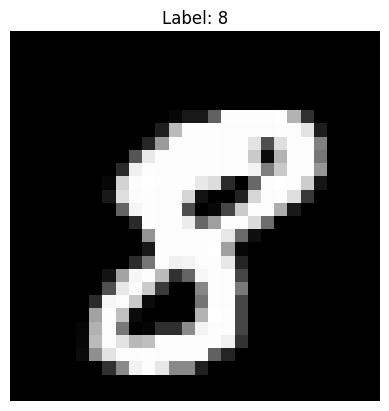

In [9]:
plt.imshow(image, cmap="gray")
plt.title(f"Label: {image_label}")
plt.axis("off")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [11]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

X = df.iloc[:, 1:].values.astype(np.float32) / 255.0
y = df.iloc[:, 0].values.astype(np.int64)

In [12]:
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [14]:
input_size   = 784     # Each image is 28x28 pixels
hidden_size1 = 128     # First hidden layer neurons
hidden_size2 = 64      # Second hidden layer neurons
output_size  = 10      # 10 classes for digits 0-9

alpha   = 0.001        # Learning rate
beta1   = 0.9          # Adam optimizer parameter
beta2   = 0.999        # Adam optimizer parameter
epsilon = 1e-8         # Small constant to prevent division by zero

# Xavier (He) initialization for weights and zero initialization for biases.
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size1) * np.sqrt(2.0 / input_size)
b1 = np.zeros((1, hidden_size1))
W2 = np.random.randn(hidden_size1, hidden_size2) * np.sqrt(2.0 / hidden_size1)
b2 = np.zeros((1, hidden_size2))
W3 = np.random.randn(hidden_size2, output_size) * np.sqrt(2.0 / hidden_size2)
b3 = np.zeros((1, output_size))

# Initialize Adam optimizer variables (moving averages and variances) for each layer.
moving_avg_W1, moving_var_W1 = np.zeros_like(W1), np.zeros_like(W1)
moving_avg_b1, moving_var_b1 = np.zeros_like(b1), np.zeros_like(b1)
moving_avg_W2, moving_var_W2 = np.zeros_like(W2), np.zeros_like(W2)
moving_avg_b2, moving_var_b2 = np.zeros_like(b2), np.zeros_like(b2)
moving_avg_W3, moving_var_W3 = np.zeros_like(W3), np.zeros_like(W3)
moving_avg_b3, moving_var_b3 = np.zeros_like(b3), np.zeros_like(b3)

In [15]:
def relu(Z):
    return np.maximum(0, Z)

In [16]:
def softmax(Z):
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [17]:
def compute_loss(Y, Y_hat):
    return -np.mean(Y * np.log(Y_hat + epsilon))

In [23]:
def forward_propagation(X):
    """
    Perform forward propagation through the network.
    Returns:
      Z1, A1, Z2, A2, Z3, A3: Intermediate computations for backpropagation.
    """
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [24]:
def backward_propagation(X, Y, Z1, A1, Z2, A2, Z3, A3):
    """
    Perform backward propagation to compute gradients for all parameters.
    Returns:
      Gradients for W1, b1, W2, b2, W3, b3.
    """
    m = X.shape[0]  # number of samples in the batch

    # Output layer gradients
    dZ3 = A3 - Y
    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Second hidden layer gradients
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * (Z2 > 0)  # derivative of ReLU
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # First hidden layer gradients
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)  # derivative of ReLU
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [25]:
def adam_update(time_step, weight_gradient, bias_gradient, moving_avg_weight, moving_var_weight, moving_avg_bias, moving_var_bias):
    """
    Update parameters using the Adam optimization algorithm.
    Returns:
      weight_update, bias_update and updated moving averages and variances.
    """
    # Compute moving averages for weight gradients
    moving_avg_weight = beta1 * moving_avg_weight + (1 - beta1) * weight_gradient
    moving_var_weight = beta2 * moving_var_weight + (1 - beta2) * (weight_gradient ** 2)

    # Compute moving averages for bias gradients
    moving_avg_bias = beta1 * moving_avg_bias + (1 - beta1) * bias_gradient
    moving_var_bias = beta2 * moving_var_bias + (1 - beta2) * (bias_gradient ** 2)

    # Apply weight and bias correction
    corrected_moving_avg_weight = moving_avg_weight / (1 - beta1 ** time_step)
    corrected_moving_var_weight = moving_var_weight / (1 - beta2 ** time_step)

    corrected_moving_avg_bias = moving_avg_bias / (1 - beta1 ** time_step)
    corrected_moving_var_bias = moving_var_bias / (1 - beta2 ** time_step)

    # Compute weight and bias updates
    weight_update = alpha * corrected_moving_avg_weight / (np.sqrt(corrected_moving_var_weight) + epsilon)
    bias_update = alpha * corrected_moving_avg_bias / (np.sqrt(corrected_moving_var_bias) + epsilon)

    return weight_update, bias_update, moving_avg_weight, moving_var_weight, moving_avg_bias, moving_var_bias

In [26]:
epochs = 10
batch_size = 32

In [27]:
for epoch in range(epochs):
  for i in range(0, X_train.shape[0], batch_size):
    X_batch = X_train[i: i+batch_size]
    Y_batch = y_train[i: i+batch_size]

    Z1, A1, Z2, A2, Z3, A3 = forward_propogation(X_batch)

    dW1, db1, dW2, db2, dW3, db3 = backward_propogation(X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3)

    W1_update, b1_update, moving_avg_W1, moving_var_W1, moving_avg_b1, moving_var_b1 = adam_update(epoch + 1, dW1, db1, moving_avg_W1, moving_var_W1, moving_avg_b1, moving_var_b1)

    W2_update, b2_update, moving_avg_W2, moving_var_W2, moving_avg_b2, moving_var_b2 = adam_update(epoch + 1, dW2, db2, moving_avg_W2, moving_var_W2, moving_avg_b2, moving_var_b2)

    W3_update, b3_update, moving_avg_W3, moving_var_W3, moving_avg_b3, moving_var_b3 = adam_update(epoch + 1, dW3, db3, moving_avg_W3, moving_var_W3, moving_avg_b3, moving_var_b3)

    W1 -= W1_update
    b1 -= b1_update
    W2 -= W2_update
    b2 -= b2_update
    W3 -= W3_update
    b3 -= b3_update

  _, _, _, _, _, A3 = forward_propagation(X_train)
  loss = compute_loss(y_train, A3)
  print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 1/10, Loss: 0.0115
Epoch 2/10, Loss: 0.0090
Epoch 3/10, Loss: 0.0075
Epoch 4/10, Loss: 0.0065
Epoch 5/10, Loss: 0.0057
Epoch 6/10, Loss: 0.0051
Epoch 7/10, Loss: 0.0046
Epoch 8/10, Loss: 0.0041
Epoch 9/10, Loss: 0.0037
Epoch 10/10, Loss: 0.0033


In [29]:
_, _, _, _, _, A3_test = forward_propagation(X_test)
predictions = np.argmax(A3_test, axis=1)
labels = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 96.74%


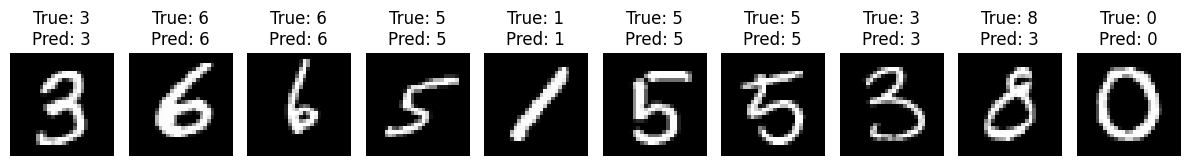

In [30]:
n_images = 10
plt.figure(figsize=(12, 6))
for i in range(n_images):
    plt.subplot(1, n_images, i + 1)
    image = X_val[i].reshape(28, 28)

    _, _, _, _, _, A3_val = forward_propagation(X_val[i].reshape(1, -1))
    predicted_label = np.argmax(A3_val, axis=1)[0]
    true_label = np.argmax(y_val[i])

    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
plt.tight_layout()
plt.show()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [32]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (26880, 784), y_train shape: (26880,)
X_val shape: (6720, 784), y_val shape: (6720,)


In [33]:
X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0

In [36]:
import tensorflow as tf

2025-02-25 15:10:09.022253: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [37]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape = (784, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [38]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [39]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10


2025-02-25 15:13:37.958297: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 84295680 exceeds 10% of free system memory.


840/840 [==============================] - 4s 4ms/step - loss: 1.2745 - accuracy: 0.5846 - val_loss: 0.6652 - val_accuracy: 0.7990
Epoch 2/10
840/840 [==============================] - 3s 3ms/step - loss: 0.5868 - accuracy: 0.8172 - val_loss: 0.4495 - val_accuracy: 0.8714
Epoch 3/10
840/840 [==============================] - 3s 3ms/step - loss: 0.4513 - accuracy: 0.8656 - val_loss: 0.3858 - val_accuracy: 0.8885
Epoch 4/10
840/840 [==============================] - 3s 3ms/step - loss: 0.3935 - accuracy: 0.8834 - val_loss: 0.3384 - val_accuracy: 0.8997
Epoch 5/10
840/840 [==============================] - 3s 3ms/step - loss: 0.3516 - accuracy: 0.8958 - val_loss: 0.3081 - val_accuracy: 0.9073
Epoch 6/10
840/840 [==============================] - 3s 3ms/step - loss: 0.3170 - accuracy: 0.9060 - val_loss: 0.2871 - val_accuracy: 0.9128
Epoch 7/10
840/840 [==============================] - 3s 3ms/step - loss: 0.2894 - accuracy: 0.9136 - val_loss: 0.2701 - val_accuracy: 0.9211
Epoch 8/10
840/84

In [40]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

263/263 [==============================] - 1s 2ms/step - loss: 0.2185 - accuracy: 0.9344
Test Accuracy: 0.93


In [44]:
n_images = 1000

1/1 [==============================] - 0s 18ms/step


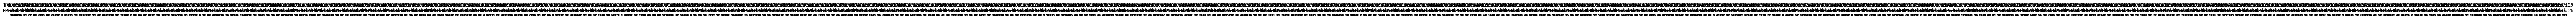

In [45]:
plt.figure(figsize=(120, 60))

for i in range(n_images):
    image = X_test[i].reshape(28, 28)
    label = y_test[i]
    model_prediction = model.predict(X_test[i].reshape(1, 784)).argmax()

    plt.subplot(1, n_images, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title(f"True: {label}\nPred: {model_prediction}")

plt.show()